# 作业D：奇偶位置拆分与对角重采样

本作业使用 NumPy 切片，将图像按照行列索引的奇偶性拆分为
四幅子图，并研究对角子图之间的关系、噪声独立性以及尺寸恢复方法。

In [15]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

height = 256
width = 256

# 创建横向渐变背景
background = np.linspace(
    0.05,
    0.35,
    width,
    dtype=np.float32
)

clean_image = np.zeros(
    (height, width),
    dtype=np.float32
)

clean_image[:, :] = background

# 添加图像结构
clean_image[40:216, 40:216] = 0.50
clean_image[80:176, 80:176] = 0.85

# 添加独立高斯噪声
rng = np.random.default_rng(
    seed=42
)

noise = rng.normal(
    loc=0.0,
    scale=0.08,
    size=clean_image.shape
).astype(np.float32)

noisy_image = np.clip(
    clean_image + noise,
    0.0,
    1.0
)

print("干净图像形状：", clean_image.shape)
print("噪声图像形状：", noisy_image.shape)

干净图像形状： (256, 256)
噪声图像形状： (256, 256)


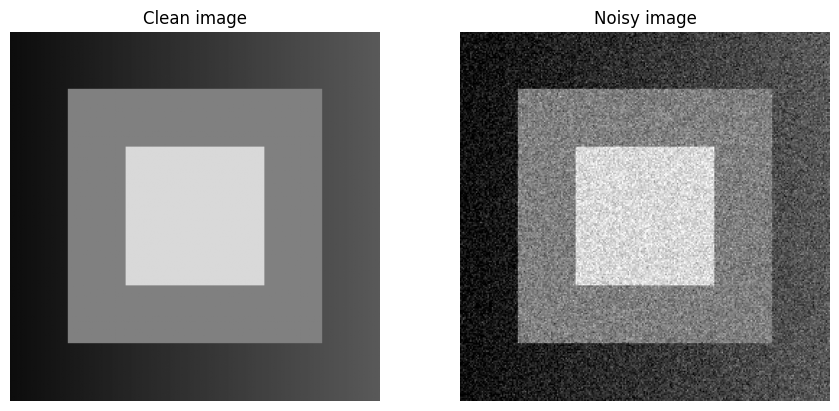

In [16]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4),
    constrained_layout=True
)

axes[0].imshow(
    clean_image,
    cmap="gray",
    vmin=0.0,
    vmax=1.0
)

axes[0].set_title("Clean image")
axes[0].axis("off")

axes[1].imshow(
    noisy_image,
    cmap="gray",
    vmin=0.0,
    vmax=1.0
)

axes[1].set_title("Noisy image")
axes[1].axis("off")

plt.show()

In [17]:
even_even = noisy_image[
    0::2,
    0::2
]

even_odd = noisy_image[
    0::2,
    1::2
]

odd_even = noisy_image[
    1::2,
    0::2
]

odd_odd = noisy_image[
    1::2,
    1::2
]

print("原始图像形状：", noisy_image.shape)
print("偶数行、偶数列：", even_even.shape)
print("偶数行、奇数列：", even_odd.shape)
print("奇数行、偶数列：", odd_even.shape)
print("奇数行、奇数列：", odd_odd.shape)

原始图像形状： (256, 256)
偶数行、偶数列： (128, 128)
偶数行、奇数列： (128, 128)
奇数行、偶数列： (128, 128)
奇数行、奇数列： (128, 128)


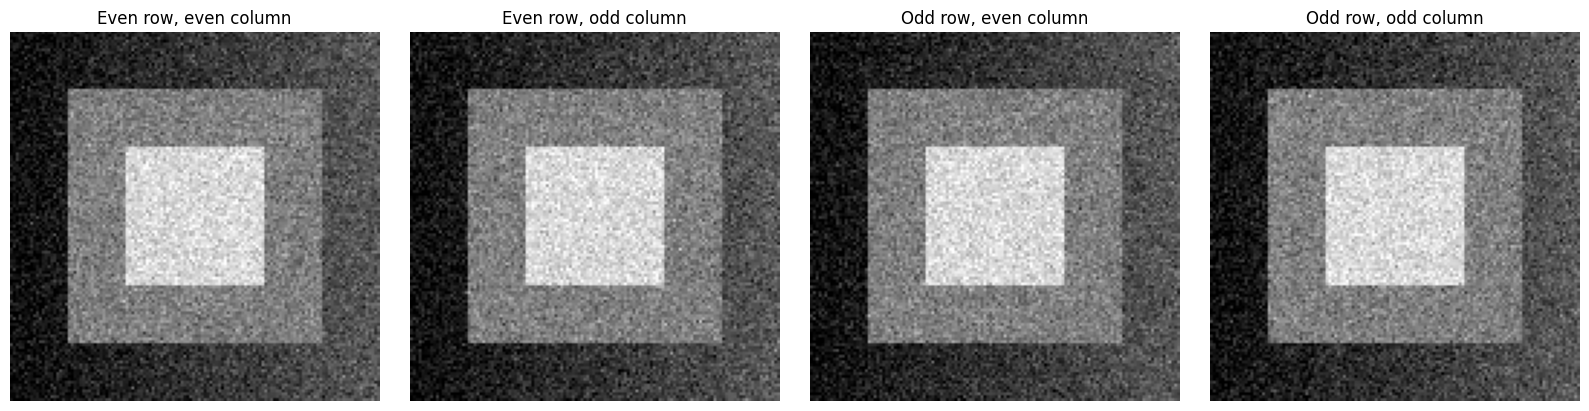

In [18]:
subimages = [
    even_even,
    even_odd,
    odd_even,
    odd_odd
]

subimage_titles = [
    "Even row, even column",
    "Even row, odd column",
    "Odd row, even column",
    "Odd row, odd column"
]

fig_subimages, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
    constrained_layout=True
)

for ax, current_image, title in zip(
    axes,
    subimages,
    subimage_titles
):
    ax.imshow(
        current_image,
        cmap="gray",
        vmin=0.0,
        vmax=1.0
    )

    ax.set_title(title)
    ax.axis("off")

plt.show()

In [19]:
diagonal_image_a = even_even
diagonal_image_b = odd_odd

print(
    "对角子图A形状：",
    diagonal_image_a.shape
)

print(
    "对角子图B形状：",
    diagonal_image_b.shape
)

对角子图A形状： (128, 128)
对角子图B形状： (128, 128)


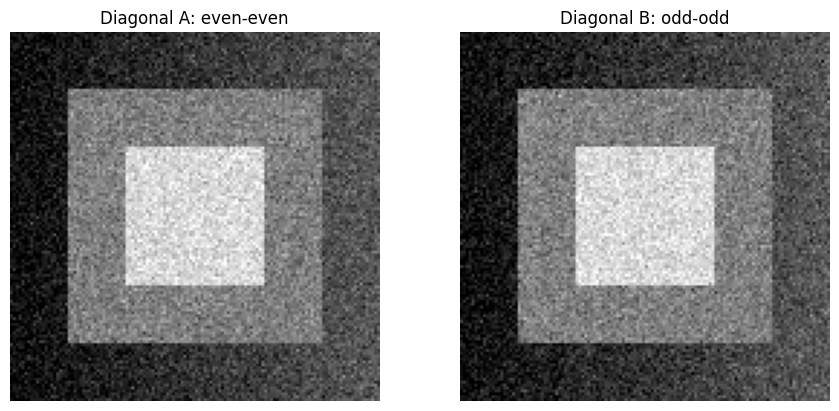

In [20]:
fig_diagonal, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4),
    constrained_layout=True
)

axes[0].imshow(
    diagonal_image_a,
    cmap="gray",
    vmin=0.0,
    vmax=1.0
)

axes[0].set_title(
    "Diagonal A: even-even"
)
axes[0].axis("off")

axes[1].imshow(
    diagonal_image_b,
    cmap="gray",
    vmin=0.0,
    vmax=1.0
)

axes[1].set_title(
    "Diagonal B: odd-odd"
)
axes[1].axis("off")

plt.show()

In [21]:
clean_diagonal_a = clean_image[
    0::2,
    0::2
]

clean_diagonal_b = clean_image[
    1::2,
    1::2
]

noise_diagonal_a = noise[
    0::2,
    0::2
]

noise_diagonal_b = noise[
    1::2,
    1::2
]

In [22]:
signal_mean_difference = np.mean(
    np.abs(
        clean_diagonal_a
        - clean_diagonal_b
    )
)

print(
    "两幅干净子图的平均绝对差异：",
    signal_mean_difference
)

两幅干净子图的平均绝对差异： 0.0006204045


In [23]:
noise_correlation = np.corrcoef(
    noise_diagonal_a.ravel(),
    noise_diagonal_b.ravel()
)[0, 1]

noisy_image_correlation = np.corrcoef(
    diagonal_image_a.ravel(),
    diagonal_image_b.ravel()
)[0, 1]

print(
    "两幅噪声的相关系数：",
    noise_correlation
)

print(
    "两幅含噪子图的相关系数：",
    noisy_image_correlation
)

两幅噪声的相关系数： 0.00493105415908252
两幅含噪子图的相关系数： 0.905824649611722


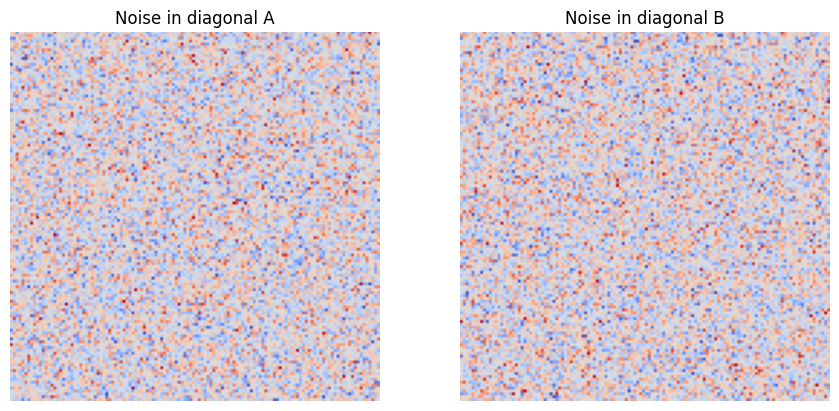

In [24]:
fig_noise, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4),
    constrained_layout=True
)

axes[0].imshow(
    noise_diagonal_a,
    cmap="coolwarm",
    vmin=-0.24,
    vmax=0.24
)

axes[0].set_title(
    "Noise in diagonal A"
)
axes[0].axis("off")

axes[1].imshow(
    noise_diagonal_b,
    cmap="coolwarm",
    vmin=-0.24,
    vmax=0.24
)

axes[1].set_title(
    "Noise in diagonal B"
)
axes[1].axis("off")

plt.show()

In [25]:
reconstructed_all = np.zeros_like(
    noisy_image
)

reconstructed_all[
    0::2,
    0::2
] = even_even

reconstructed_all[
    0::2,
    1::2
] = even_odd

reconstructed_all[
    1::2,
    0::2
] = odd_even

reconstructed_all[
    1::2,
    1::2
] = odd_odd

print(
    "重建图像形状：",
    reconstructed_all.shape
)

print(
    "是否与原图完全一致：",
    np.array_equal(
        reconstructed_all,
        noisy_image
    )
)

print(
    "最大绝对误差：",
    np.max(
        np.abs(
            reconstructed_all
            - noisy_image
        )
    )
)

重建图像形状： (256, 256)
是否与原图完全一致： True
最大绝对误差： 0.0


In [26]:
zero_filled_pair = np.zeros_like(
    noisy_image
)

sampling_mask = np.zeros(
    noisy_image.shape,
    dtype=bool
)

# 放回左上角采样点
zero_filled_pair[
    0::2,
    0::2
] = diagonal_image_a

sampling_mask[
    0::2,
    0::2
] = True

# 放回右下角采样点
zero_filled_pair[
    1::2,
    1::2
] = diagonal_image_b

sampling_mask[
    1::2,
    1::2
] = True

print(
    "零值填充后形状：",
    zero_filled_pair.shape
)

print(
    "保留像素比例：",
    sampling_mask.mean()
)

print(
    "缺失像素比例：",
    1.0 - sampling_mask.mean()
)

零值填充后形状： (256, 256)
保留像素比例： 0.5
缺失像素比例： 0.5


In [27]:
from scipy import ndimage

interpolated_a = ndimage.zoom(
    diagonal_image_a,
    zoom=(2, 2),
    order=1
)

interpolated_b = ndimage.zoom(
    diagonal_image_b,
    zoom=(2, 2),
    order=1
)

print(
    "子图A插值后形状：",
    interpolated_a.shape
)

print(
    "子图B插值后形状：",
    interpolated_b.shape
)

子图A插值后形状： (256, 256)
子图B插值后形状： (256, 256)


In [29]:
interpolated_average = (
    interpolated_a
    + interpolated_b
) / 2.0

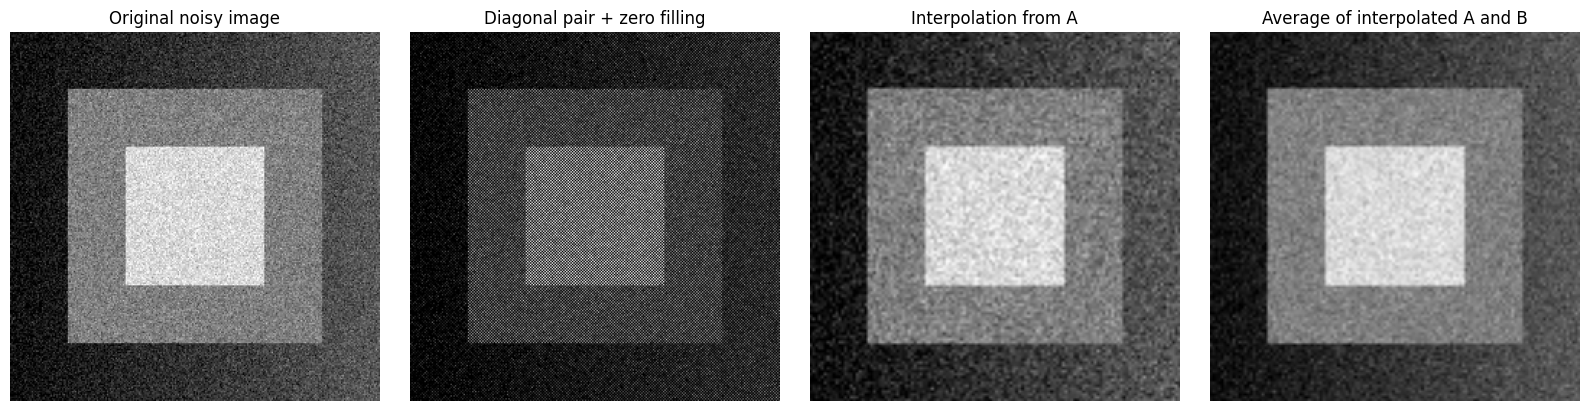

In [30]:
restored_images = [
    noisy_image,
    zero_filled_pair,
    interpolated_a,
    interpolated_average
]

restored_titles = [
    "Original noisy image",
    "Diagonal pair + zero filling",
    "Interpolation from A",
    "Average of interpolated A and B"
]

fig_restoration, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
    constrained_layout=True
)

for ax, current_image, title in zip(
    axes,
    restored_images,
    restored_titles
):
    ax.imshow(
        current_image,
        cmap="gray",
        vmin=0.0,
        vmax=1.0
    )

    ax.set_title(title)
    ax.axis("off")

plt.show()